In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
a, v0, g, d2, tmax = 0, 0.5, 0.05, 0, 500

!gfortran rtpcode.f90 -o rtp
!echo "{a} {v0} {g} {d2} {tmax}" | ./rtp

 Input initial position a, speed v0, gamma, d2, tmax


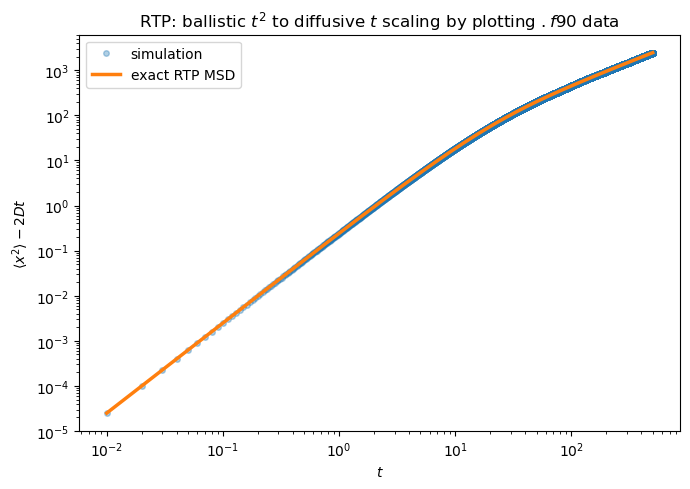

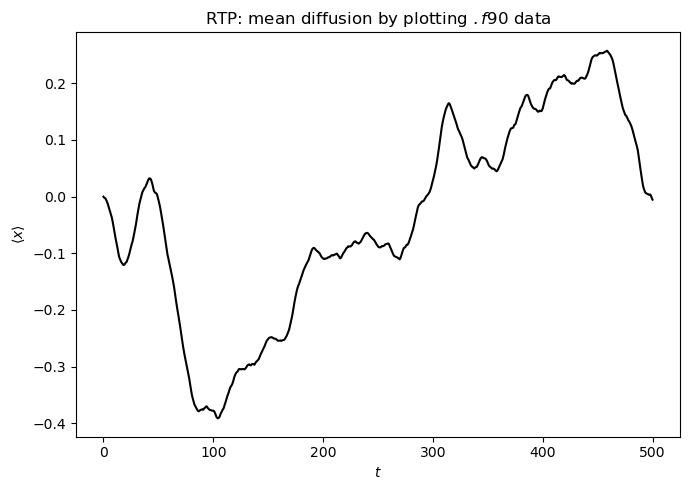

In [3]:
file_path = Path("RTP_data.dat").expanduser()
t, avgx, avgxx = np.loadtxt(file_path, unpack=True)
x, y = t, avgx

mask = (t > 0) & (avgxx > 0)
t = t[mask]
avgxx = avgxx[mask]

# exact RTP MSD contribution
avgxx_exact = v0**2 * (t/g - (1.0 - np.exp(-2*g*t))/(2*g**2))

plt.figure(figsize=(7,5))

plt.loglog(t, avgxx, 'o', ms=4, alpha=0.35, label="simulation")
plt.loglog(t, avgxx_exact, lw=2.5, label="exact RTP MSD")

plt.xlabel(r"$t$")
plt.ylabel(r"$\langle x^2\rangle - 2Dt$")
plt.title(r"RTP: ballistic $t^2$ to diffusive $t$ scaling by plotting $.f90$ data")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))

plt.plot(x, y, color='k')
plt.xlabel(r"$t$")
plt.ylabel(r"$\langle x\rangle$")
plt.title(r"RTP: mean diffusion by plotting $.f90$ data")
plt.tight_layout()

In [9]:
D_r, mu = 0.05, 0.0

!gfortran abpcode.f90 -o abp
!echo "{D_r}, {mu}" | ./abp

 Input the values of initial D_r and Mu


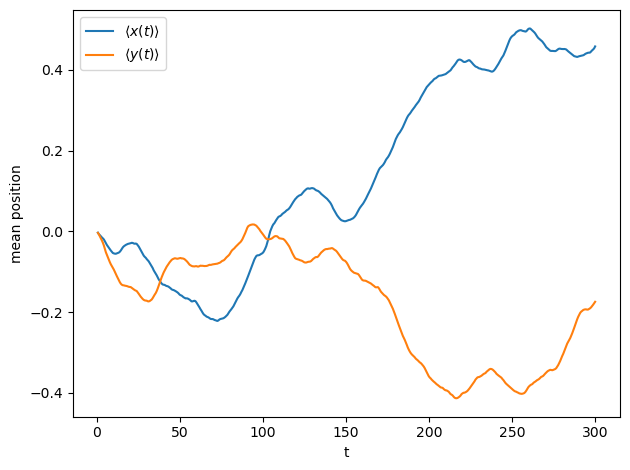

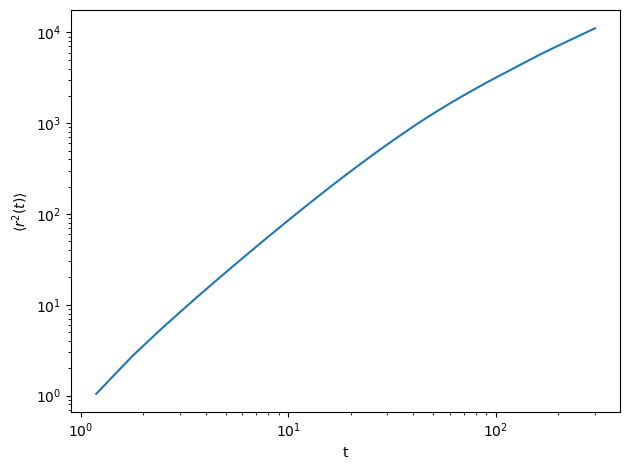

In [22]:
data = np.loadtxt("ABP_data.dat")

t = data[:,0]
avgx = data[:,1]
avgy = data[:,2]
avgx2 = data[:,3]
avgy2 = data[:,4]
avgr2 = data[:,5]

plt.plot(t, avgx, label=r"$\langle x(t)\rangle$")
plt.plot(t, avgy, label=r"$\langle y(t)\rangle$")
plt.xlabel("t")
plt.ylabel("mean position")
plt.legend()
plt.tight_layout()
plt.show()

plt.loglog(t[1:], avgr2[1:]-np.full(len(avgr2), avgr2[0])[1:])
plt.xlabel("t")
plt.ylabel(r"$\langle r^2(t)\rangle$")
plt.tight_layout()
plt.show()

array([0.34469417, 0.34469417, 0.34469417, 0.34469417, 0.34469417,
       0.34469417, 0.34469417, 0.34469417, 0.34469417, 0.34469417,
       0.34469417, 0.34469417, 0.34469417, 0.34469417, 0.34469417,
       0.34469417, 0.34469417, 0.34469417, 0.34469417, 0.34469417,
       0.34469417, 0.34469417, 0.34469417, 0.34469417, 0.34469417,
       0.34469417, 0.34469417, 0.34469417, 0.34469417, 0.34469417,
       0.34469417, 0.34469417, 0.34469417, 0.34469417, 0.34469417,
       0.34469417, 0.34469417, 0.34469417, 0.34469417, 0.34469417,
       0.34469417, 0.34469417, 0.34469417, 0.34469417, 0.34469417,
       0.34469417, 0.34469417, 0.34469417, 0.34469417, 0.34469417,
       0.34469417, 0.34469417, 0.34469417, 0.34469417, 0.34469417,
       0.34469417, 0.34469417, 0.34469417, 0.34469417, 0.34469417,
       0.34469417, 0.34469417, 0.34469417, 0.34469417, 0.34469417,
       0.34469417, 0.34469417, 0.34469417, 0.34469417, 0.34469417,
       0.34469417, 0.34469417, 0.34469417, 0.34469417, 0.34469